Task 1 — Build Dataset & Regression Mode

Create synthetic dataset:

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Create dataset
np.random.seed(42)
data = pd.DataFrame({
    'area_sqft': np.random.randint(800, 3000, 50),
    'num_bedrooms': np.random.randint(1, 5, 50),
    'age_years': np.random.randint(1, 30, 50)
})

# Target variable (price in lakhs) with some noise
data['price_lakhs'] = (
    0.85 * data['area_sqft'] +
    30 * data['num_bedrooms'] -
    5 * data['age_years'] +
    np.random.randint(-20000, 20000, 50)
) / 1000  # scaled to lakhs

Train regression model

In [2]:
X = data[['area_sqft', 'num_bedrooms', 'age_years']]
y = data['price_lakhs']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

Intercept: 1.4914100701544277
Coefficients: {'area_sqft': np.float64(0.0002520077128883043), 'num_bedrooms': np.float64(0.049227099915488765), 'age_years': np.float64(-0.08260943015751453)}


Show first 5 predictions

In [3]:
predictions = model.predict(X)
results = pd.DataFrame({'Actual': y[:5], 'Predicted': predictions[:5]})
print(results)

     Actual  Predicted
0   3.85900   1.760369
1  -0.02410   2.034959
2  -3.55450  -0.055761
3 -11.98025   1.654372
4 -16.23970   1.378165


Task 2 — Evaluate Mode

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Comments:
# MAE → average error in lakhs (easy to interpret).
# RMSE → penalizes large errors more, shows sensitivity to outliers.
# R² → explains % of variance in house prices captured by the model.

MAE: 9.407178915040497
RMSE: 10.919348901605789
R²: 0.004713676526159616


Task 3 — Residuals & Histogra

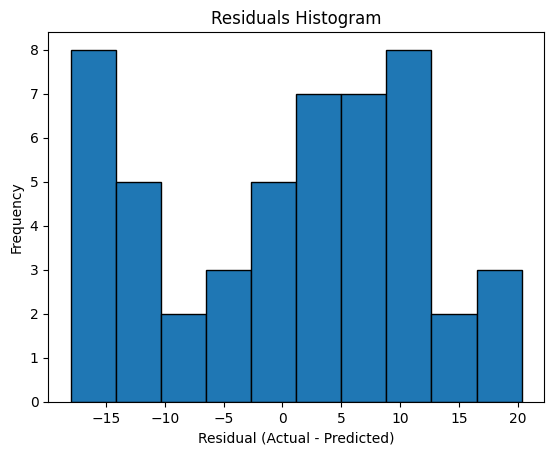

In [5]:
import matplotlib.pyplot as plt

residuals = y - predictions

plt.hist(residuals, bins=10, edgecolor='black')
plt.title("Residuals Histogram")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

# Comment:
# Residual = Actual - Predicted.
# If histogram is centered around 0 and roughly symmetric,
# model errors are balanced → good fit.
# Skewed or wide spread → bias or poor generalization.